# Scenario 3 analysis

In [3]:
import maboss
import matplotlib.pyplot as plt
from collections import OrderedDict

In [4]:
output_gpt5 =  "Gpt_5/Scenario_3/"
output_sonnet4 = "Sonnet_4/Scenario_3/"
output_gpt_o4 = "Gpt_o4_mini/Scenario_3/"

In [5]:
masim_gpt5 = maboss.load(output_gpt5 + "output.bnd", output_gpt5 + "output.cfg")

masim_gpt5.network.set_output([ "CASP3", "RIPK3", "BAX", "NFKB1"])
masim_gpt5.param["max_time"]=20
masim_gpt5.param["thread_count"]=8

masim_gpto4 = maboss.load(output_gpt_o4 + "output.bnd", output_gpt_o4 + "output.cfg")
masim_gpto4.param["max_time"]=20
masim_gpto4.param["thread_count"]=8
masim_gpto4.network.set_output([ "CASP3", "BAX", "NFKB1"])

masim_sonnet4 = maboss.load(output_sonnet4 + "output.bnd", output_sonnet4 + "output.cfg")
masim_sonnet4.param["max_time"]=20
masim_sonnet4.param["thread_count"]=8
masim_sonnet4.network.set_output([ "CASP3", "BAX", "NFKB1"])

In [12]:
tnf_simple_bnd = "Boolean_network/cellfate.bnd"
tnf_simple_cfg = "Boolean_network/cellfate.cfg"

masim_tnf = maboss.load(tnf_simple_bnd, tnf_simple_cfg)

for node in list(masim_tnf.network.keys()):
    masim_tnf.network.set_istate(node, [0.5, 0.5])

masim_tnf.update_parameters(max_time=20, sample_count=10000)

masim_tnf.network.set_output(["BAX", "CASP3", "NFkB", "RIP1K"])

results_tnf = masim_tnf.run()

results_tnf.plot_piechart()

In [13]:
results_gpto4 = masim_gpto4.run()
results_gpt5 = masim_gpt5.run()
results_sonnet4 = masim_sonnet4.run()

In [14]:
results_gpto4.plot_piechart()

In [15]:
results_gpt5.plot_piechart()

In [16]:
results_sonnet4.plot_piechart()

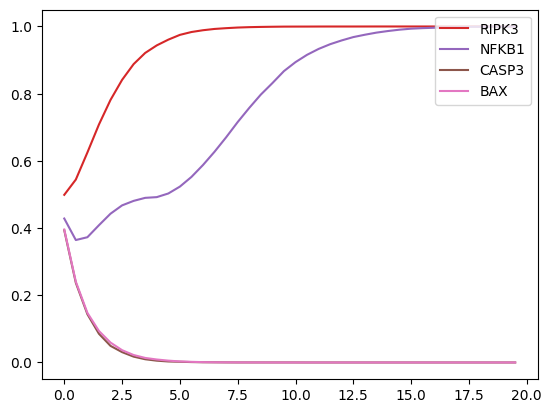

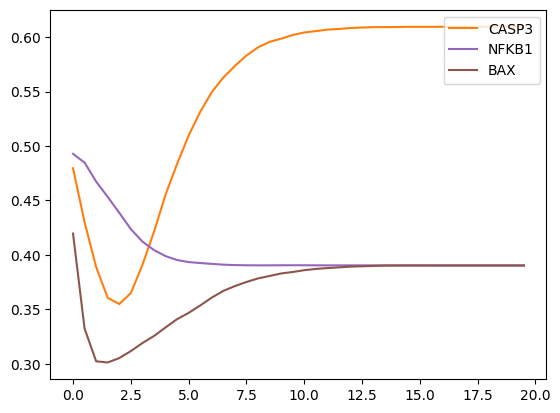

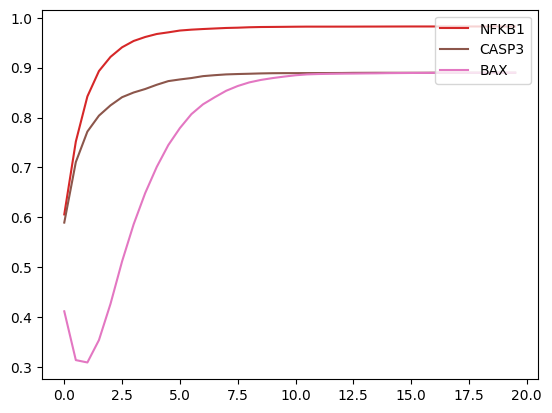

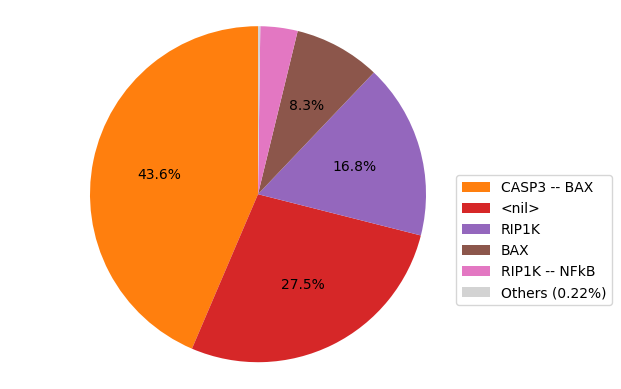

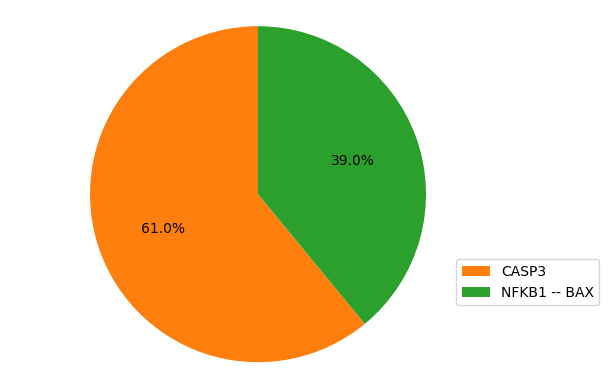

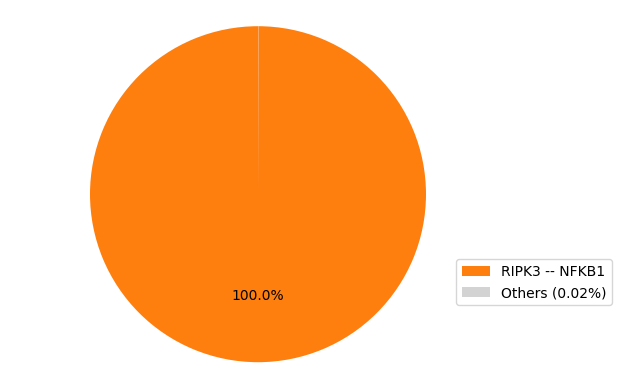

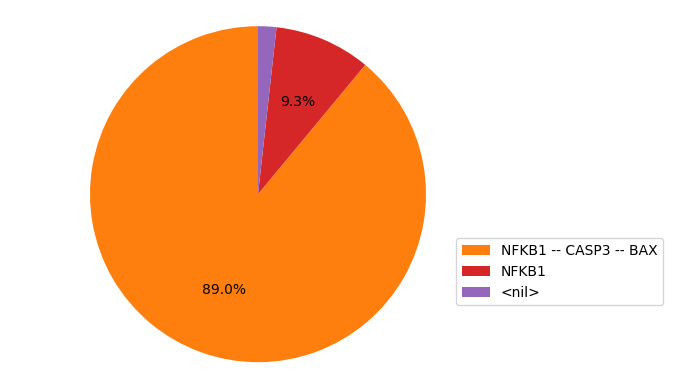

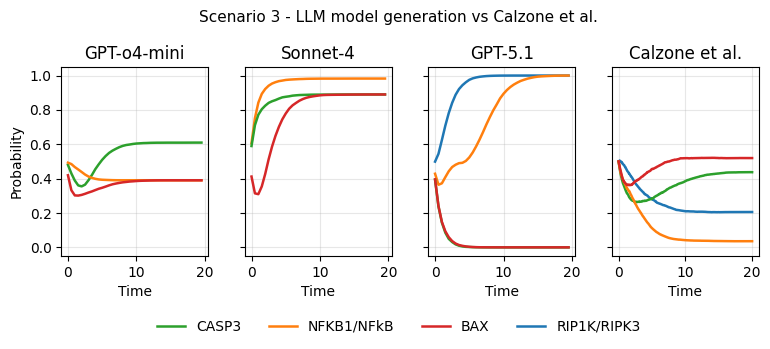

In [17]:
LABEL_ALIASES = {
    "NFkB":  "NFKB1/NFkB",
    "NFKB1": "NFKB1/NFkB",
    "RIP1K": "RIP1K/RIPK3",
    "RIPK3": "RIP1K/RIPK3",
}

def normalize_label(lab):
    return LABEL_ALIASES.get(lab, lab)

def new_figures_after(func):
    """Run func(); return fig objects created by it."""
    before = set(plt.get_fignums())
    func()
    after = set(plt.get_fignums())
    return [plt.figure(n) for n in sorted(after - before)]

def get_label(line):
    lab = line.get_label()
    return None if not lab or lab.startswith("_") else lab

def extract_model_data(figs):
    """Extract {normalized_label: (x, y)} from matplotlib figures.
    When two raw labels map to the same normalized label the first one wins."""
    data = {}
    for f in figs:
        for ax in f.axes:
            for ln in ax.get_lines():
                raw = get_label(ln)
                if raw:
                    lab = normalize_label(raw)
                    if lab not in data:          # keep first occurrence
                        data[lab] = (ln.get_xdata(), ln.get_ydata())
    return data

def build_color_map(*dicts):
    palette = ["#1f77b4","#ff7f0e","#2ca02c","#d62728",
               "#9467bd","#8c564b","#e377c2","#7f7f7f",
               "#bcbd22","#17becf"]
    all_labels = []
    for d in dicts:
        all_labels.extend(list(d.keys()))
    uniq_labels = list(OrderedDict.fromkeys(all_labels))
    return {lab: palette[i % len(palette)] for i, lab in enumerate(uniq_labels)}

# Generate plots (but don't show yet)
plt.ioff()
figs_gpt5      = new_figures_after(lambda: results_gpt5.plot_node_trajectory())
figs_gpto4     = new_figures_after(lambda: results_gpto4.plot_node_trajectory())
figs_sonnet4   = new_figures_after(lambda: results_sonnet4.plot_node_trajectory())
figs_tnf_simple = new_figures_after(lambda: results_tnf.plot_node_trajectory())
plt.ion()

# Extract data (labels already normalised inside extract_model_data)
data_gpt5      = extract_model_data(figs_gpt5)
data_gpto4     = extract_model_data(figs_gpto4)
data_sonnet4   = extract_model_data(figs_sonnet4)
data_tnf_simple = extract_model_data(figs_tnf_simple)

# Consistent colors across all panels
cmap = build_color_map(data_gpt5, data_gpto4, data_sonnet4, data_tnf_simple)
cmap.update({
    "CASP3":       "#2ca02c",  # green
    "NFKB1/NFkB":  "#ff7f0e",  # orange
    "BAX":         "#d62728",  # red
    "RIP1K/RIPK3": "#1f77b4",  # blue
})

# Build the 1×4 composite figure
fig, axes = plt.subplots(1, 4, figsize=(9, 3), sharey=True)
panels = [
    ("GPT-o4-mini",    data_gpto4,      axes[0]),
    ("Sonnet-4",       data_sonnet4,    axes[1]),
    ("GPT-5.1",        data_gpt5,       axes[2]),
    ("Calzone et al.", data_tnf_simple, axes[3]),
]

for title, dct, ax in panels:
    for lab, (x, y) in dct.items():
        ax.plot(x, y, label=lab, color=cmap[lab], linewidth=1.8)
    ax.set_title(title)
    ax.set_xlabel("Time")
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel("Probability")

fig.suptitle("Scenario 3 - LLM model generation vs Calzone et al.", y=1.07, fontsize=11)

# Shared legend: collect unique handles from ALL axes
all_handles = {}
for ax in axes:
    h, l = ax.get_legend_handles_labels()
    for handle, label in zip(h, l):
        if label not in all_handles:
            all_handles[label] = handle

fig.legend(all_handles.values(), all_handles.keys(),
           loc="lower center", ncol=len(all_handles), frameon=False,
           bbox_to_anchor=(0.5, -0.05))

plt.subplots_adjust(bottom=0.25, wspace=0.25)

# Close the original generated figures
for f in figs_gpto4 + figs_sonnet4 + figs_gpt5 + figs_tnf_simple:
    plt.close(f)

plt.show()


# Scenario 3 updated

In [18]:
output_gpt5 =  "Gpt_5/Scenario_3/gpt_pruned/"


In [19]:
masim_gpt5_pruned = maboss.load(output_gpt5 + "output.bnd", output_gpt5 + "output.cfg")

masim_gpt5_pruned.network.set_output([ "CASP3", "RIPK3", "BAX", "NFKB1"])
masim_gpt5_pruned.param["max_time"]=20
masim_gpt5_pruned.param["thread_count"]=8

In [20]:
results_gpt5_pruned = masim_gpt5_pruned.run()


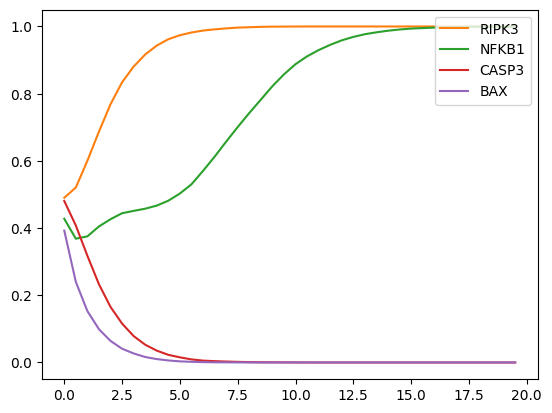

In [21]:
results_gpt5_pruned.plot_node_trajectory()

In [22]:
output_gpt5 =  "Gpt_5/Scenario_3/gpt_rules_updated/"


In [23]:
masim_gpt5_rules_updated_new = maboss.load(output_gpt5 + "TNF_TCellFate_refined.bnd", output_gpt5 + "TNF_TCellFate_refined.cfg")
for node in list(masim_gpt5_rules_updated_new.network.keys()):
    masim_gpt5_rules_updated_new.network.set_istate(node, [0.5, 0.5])
masim_gpt5_rules_updated_new.network.set_output([ "CASP3", "RIPK3", "BAX", "NFKB1"])
masim_gpt5_rules_updated_new.param["max_time"]=20
masim_gpt5_rules_updated_new.param["thread_count"]=8

In [24]:
results_gpt5_rules_updated_new = masim_gpt5_rules_updated_new.run()

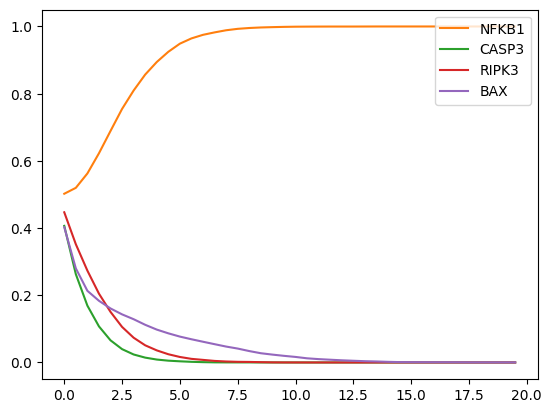

In [25]:
results_gpt5_rules_updated_new.plot_node_trajectory()

In [26]:
masim_gpt5_rules_updated_new.network.set_istate('TNF', [0, 1])

In [27]:
results_gpt5_rules_updated_new = masim_gpt5_rules_updated_new.run()

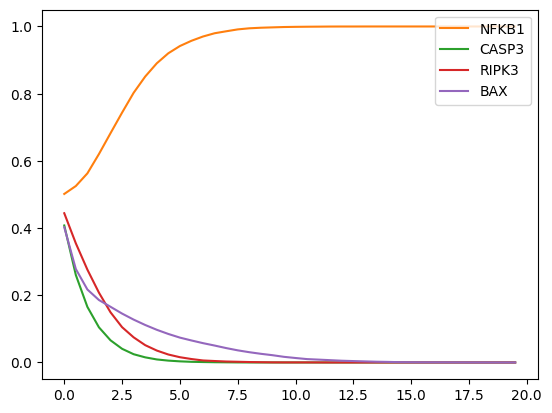

In [28]:
results_gpt5_rules_updated_new.plot_node_trajectory()

In [29]:
masim_gpt5_rules_updated_final = maboss.load(output_gpt5 + "TNF_cancer_fate_pruned_final.bnd", output_gpt5 + "TNF_cancer_fate_pruned_final.cfg")
for node in list(masim_gpt5_rules_updated_final.network.keys()):
    masim_gpt5_rules_updated_final.network.set_istate(node, [0.5, 0.5])
masim_gpt5_rules_updated_final.network.set_output([ "CASP3", "RIPK1", "BAX", "NFKB1"])
masim_gpt5_rules_updated_final.param["max_time"]=20
masim_gpt5_rules_updated_final.param["thread_count"]=8

In [30]:
results_gpt5_rules_updated_final = masim_gpt5_rules_updated_final.run()

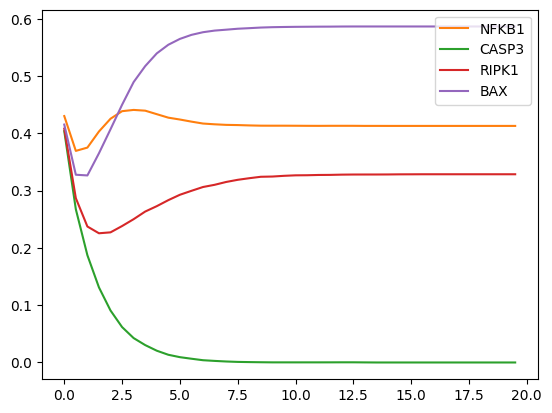

In [31]:
results_gpt5_rules_updated_final.plot_node_trajectory()

In [32]:
masim_gpt5_rules_updated_final.network.set_istate("TNF", [0.0, 1.0])

masim_gpt5_rules_updated_final.network.set_istate("TNFRSF1B", [0.0, 1.0])

masim_gpt5_rules_updated_final.network.set_istate("TNFRSF1A", [0.0, 1.0])

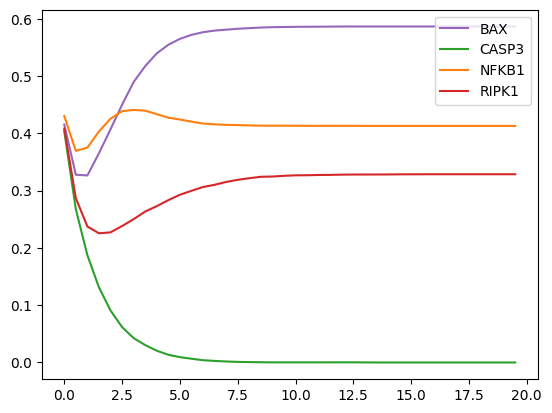

In [33]:
results_gpt5_rules_updated_final.plot_node_trajectory()

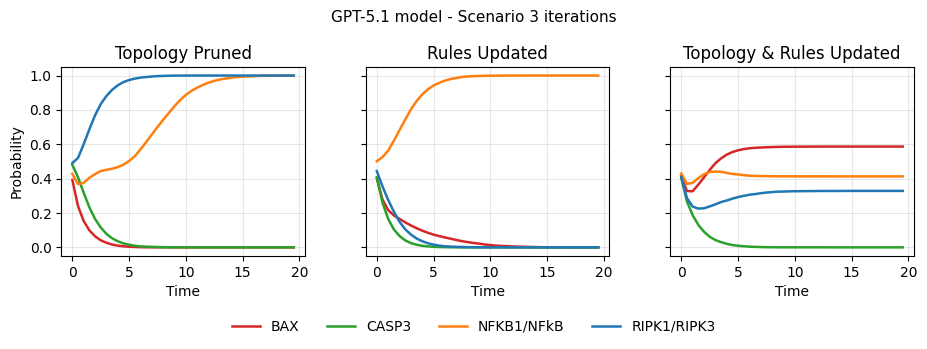

In [34]:
LABEL_ALIASES = {
    "NFkB":  "NFKB1/NFkB",
    "NFKB1": "NFKB1/NFkB",
    "RIPK1": "RIPK1/RIPK3",
    "RIPK3": "RIPK1/RIPK3",
}

def normalize_label(lab):
    return LABEL_ALIASES.get(lab, lab)

def new_figures_after(func):
    """Run func(); return fig objects created by it."""
    before = set(plt.get_fignums())
    func()
    after = set(plt.get_fignums())
    return [plt.figure(n) for n in sorted(after - before)]

def get_label(line):
    lab = line.get_label()
    return None if not lab or lab.startswith("_") else lab

def extract_model_data(figs):
    """Extract {normalized_label: (x, y)} from matplotlib figures.
    When two raw labels map to the same normalized label the first one wins."""
    data = {}
    for f in figs:
        for ax in f.axes:
            for ln in ax.get_lines():
                raw = get_label(ln)
                if raw:
                    lab = normalize_label(raw)
                    if lab not in data:          # keep first occurrence
                        data[lab] = (ln.get_xdata(), ln.get_ydata())
    return data

def build_color_map(*dicts):
    palette = ["#1f77b4","#ff7f0e","#2ca02c","#d62728",
               "#9467bd","#8c564b","#e377c2","#7f7f7f",
               "#bcbd22","#17becf"]
    all_labels = []
    for d in dicts:
        all_labels.extend(list(d.keys()))
    uniq_labels = list(OrderedDict.fromkeys(all_labels))
    return {lab: palette[i % len(palette)] for i, lab in enumerate(uniq_labels)}

# Generate plots (but don't show yet)
plt.ioff()
figs_gpt5_pruned            = new_figures_after(lambda: results_gpt5_pruned.plot_node_trajectory())
figs_gpt5_rules_updated     = new_figures_after(lambda: results_gpt5_rules_updated_new.plot_node_trajectory())
figs_gpt5_rules_updated_final = new_figures_after(lambda: results_gpt5_rules_updated_final.plot_node_trajectory())
plt.ion()

# Extract data (labels already normalised inside extract_model_data)
data_gpt5_pruned            = extract_model_data(figs_gpt5_pruned)
data_gpt5_rules_updated     = extract_model_data(figs_gpt5_rules_updated)
data_gpt5_rules_updated_final = extract_model_data(figs_gpt5_rules_updated_final)

# Consistent colors across all panels — fixed to match paper palette
cmap = build_color_map(data_gpt5_pruned, data_gpt5_rules_updated, data_gpt5_rules_updated_final)
cmap.update({
    "CASP3":       "#2ca02c",  # green
    "NFKB1/NFkB":  "#ff7f0e",  # orange
    "BAX":         "#d62728",  # red
    "RIPK1/RIPK3": "#1f77b4",  # blue
})

# Build the 1×3 composite figure
fig, axes = plt.subplots(1, 3, figsize=(11, 3), sharey=True)
panels = [
    ("Topology Pruned",        data_gpt5_pruned,             axes[0]),
    ("Rules Updated",          data_gpt5_rules_updated,      axes[1]),
    ("Topology & Rules Updated", data_gpt5_rules_updated_final, axes[2]),
]

for title, dct, ax in panels:
    for lab, (x, y) in dct.items():
        ax.plot(x, y, label=lab, color=cmap[lab], linewidth=1.8)
    ax.set_title(title)
    ax.set_xlabel("Time")
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel("Probability")

fig.suptitle("GPT-5.1 model - Scenario 3 iterations", y=1.07, fontsize=11)

# Shared legend: collect unique handles from ALL axes
all_handles = {}
for ax in axes:
    h, l = ax.get_legend_handles_labels()
    for handle, label in zip(h, l):
        if label not in all_handles:
            all_handles[label] = handle

fig.legend(all_handles.values(), all_handles.keys(),
           loc="lower center", ncol=len(all_handles), frameon=False,
           bbox_to_anchor=(0.5, -0.05))

plt.subplots_adjust(bottom=0.25, wspace=0.25)

# Close the original generated figures
for f in figs_gpt5_pruned + figs_gpt5_rules_updated + figs_gpt5_rules_updated_final:
    plt.close(f)

plt.show()
